# Workshop 4: Devanagari Handwritten Digit Classification with FCN

**Building a Fully Connected Neural Network for Multi-class Image Classification**

---

## Import Libraries

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Set seeds for reproducible results
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {tf.keras.__version__}")

TensorFlow: 2.21.0
Keras: 3.13.2


---

## Task 1: Data Preparation

Load images using PIL, normalize pixels, and one-hot encode labels.

In [2]:
# Dataset paths
train_dir = "DevanagariHandwrittenDigitDataset/Train/"
test_dir = "DevanagariHandwrittenDigitDataset/Test/"

# Image settings
img_height, img_width = 28, 28
num_classes = 10

In [3]:
def load_images_from_folder(folder):
    """Load images and labels from folder structure."""
    images, labels = [], []
    
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}
    
    print(f"Classes: {class_names}")
    
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        
        image_files = os.listdir(class_path)
        print(f"Loading {len(image_files)} images from {class_name}")
        
        for filename in image_files:
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")  # Grayscale
                img = img.resize((img_width, img_height))  # Resize to 28x28
                img = np.array(img) / 255.0  # Normalize to [0,1]
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Error: {img_path} - {e}")
    
    return np.array(images), np.array(labels)

In [4]:
# Load training data
print("Loading Training Data...")
print("="*60)
x_train, y_train = load_images_from_folder(train_dir)

# Load test data
print("\nLoading Test Data...")
print("="*60)
x_test, y_test = load_images_from_folder(test_dir)

Loading Training Data...
Classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Loading 1700 images from digit_0
Loading 1700 images from digit_1
Loading 1700 images from digit_2
Loading 1700 images from digit_3
Loading 1700 images from digit_4
Loading 1700 images from digit_5
Loading 1700 images from digit_6
Loading 1700 images from digit_7
Loading 1700 images from digit_8
Loading 1700 images from digit_9

Loading Test Data...
Classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Loading 300 images from digit_0
Loading 300 images from digit_1
Loading 300 images from digit_2
Loading 300 images from digit_3
Loading 300 images from digit_4
Loading 300 images from digit_5
Loading 300 images from digit_6
Loading 300 images from digit_7
Loading 300 images from digit_8
Loading 300 images from digit_9


In [5]:
# Reshape for Keras: (samples, height, width, channels)
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train_categorical = to_categorical(y_train, num_classes)
y_test_categorical = to_categorical(y_test, num_classes)

# Display dataset info
print("\nDataset Information:")
print("="*60)
print(f"Training: {x_train.shape}, Labels: {y_train_categorical.shape}")
print(f"Test: {x_test.shape}, Labels: {y_test_categorical.shape}")
print(f"Classes: {num_classes}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")


Dataset Information:
Training: (17000, 28, 28, 1), Labels: (17000, 10)
Test: (3000, 28, 28, 1), Labels: (3000, 10)
Classes: 10
Pixel range: [0.0, 1.0]


### Visualize Sample Images

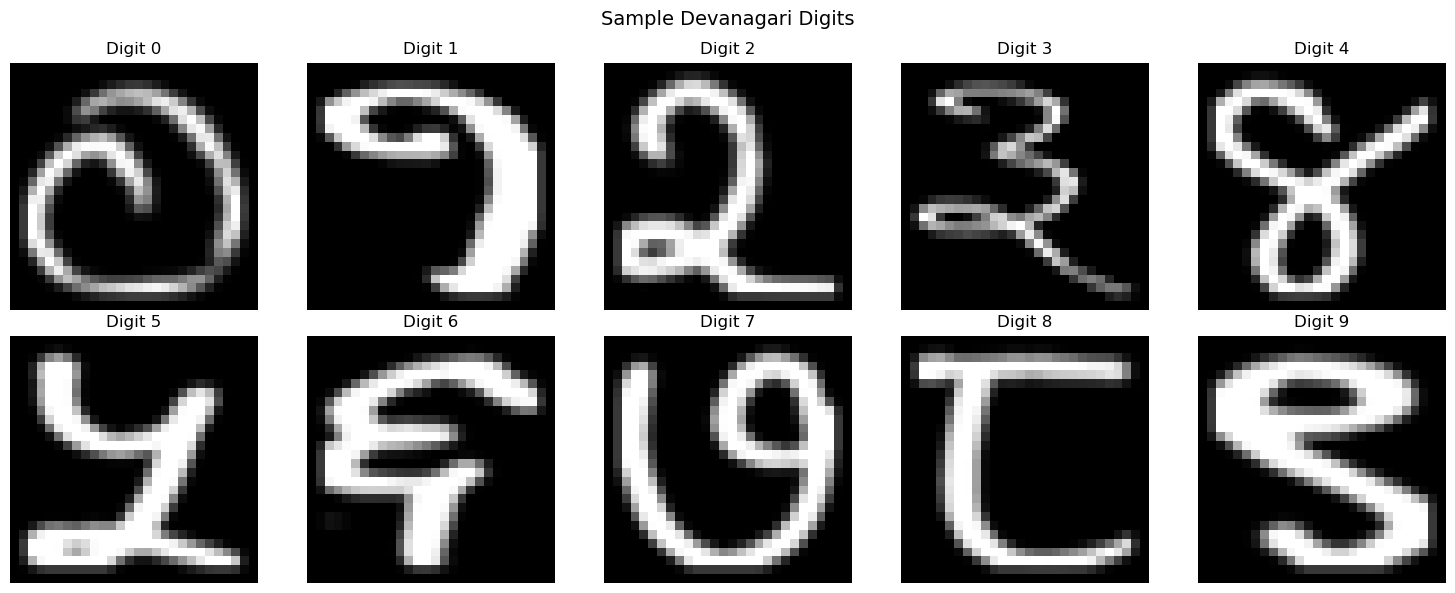

In [6]:
# Show one sample per digit class
plt.figure(figsize=(15, 6))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Digit {i}")
    plt.axis('off')
plt.suptitle('Sample Devanagari Digits', fontsize=14)
plt.tight_layout()
plt.show()

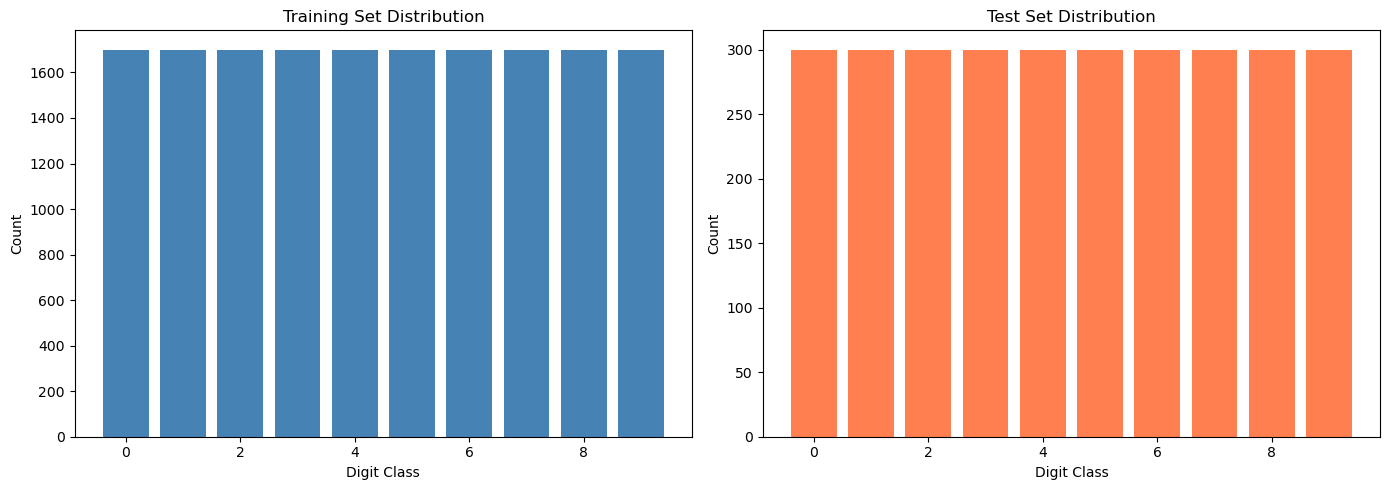

In [7]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

unique_train, counts_train = np.unique(y_train, return_counts=True)
axes[0].bar(unique_train, counts_train, color='steelblue')
axes[0].set_title('Training Set Distribution')
axes[0].set_xlabel('Digit Class')
axes[0].set_ylabel('Count')

unique_test, counts_test = np.unique(y_test, return_counts=True)
axes[1].bar(unique_test, counts_test, color='coral')
axes[1].set_title('Test Set Distribution')
axes[1].set_xlabel('Digit Class')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

---

## Task 2: Build the FCN Model

Create a Sequential model with 3 hidden layers (64, 128, 256 neurons) using sigmoid activation.

In [8]:
# Build model (high-accuracy FCN)
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),

    keras.layers.Dense(1024, activation="relu"),
    keras.layers.Dropout(0.25),

    keras.layers.Dense(512, activation="relu"),
    keras.layers.Dropout(0.25),

    keras.layers.Dense(256, activation="relu"),

    keras.layers.Dense(num_classes, activation="softmax")
], name="Devanagari_FCN")

print("Model created!")


Model created!


In [9]:
# Display model architecture
model.summary()

Model: "Devanagari_FCN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │         803,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,462,538 (5.58 MB)

 Trainable params: 1,462,538 (5.58 MB)

 Non-trainable params: 0 (0.00 B)

---

## Task 3: Compile the Model

Use Adam optimizer and categorical crossentropy loss.

In [10]:
# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled!")
print("Optimizer: Adam (lr=0.0005)")
print("Loss: Categorical Crossentropy")
print("Metrics: Accuracy")


Model compiled!
Optimizer: Adam (lr=0.0005)
Loss: Categorical Crossentropy
Metrics: Accuracy


---

## Task 4: Train the Model

Train for 20 epochs with batch size 128 and 20% validation split.

In [11]:
# Training settings
batch_size = 128
epochs = 20

# Callbacks
callbacks = [
    ModelCheckpoint(
        "best_devanagari_fcn_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print(f"Batch Size: {batch_size}")
print(f"Epochs: {epochs}")
print("Validation Split: 10%")
print("Callbacks: Checkpoint + EarlyStopping + ReduceLROnPlateau")
print("\nStarting training...\n")


Batch Size: 128
Epochs: 20
Validation Split: 10%
Callbacks: Checkpoint + EarlyStopping + ReduceLROnPlateau

Starting training...



In [12]:
# Train the model
history = model.fit(
    x_train,
    y_train_categorical,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")

Epoch 1/20
119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7654 - loss: 0.7572
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_devanagari_fcn_model.keras

Epoch 1: finished saving model to best_devanagari_fcn_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8795 - loss: 0.3839 - val_accuracy: 0.0000e+00 - val_loss: 11.1227 - learning_rate: 5.0000e-04
Epoch 2/20
119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9612 - loss: 0.1216
Epoch 2: val_accuracy did not improve from 0.00000
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9667 - loss: 0.1058 - val_accuracy: 0.0000e+00 - val_loss: 10.9650 - learning_rate: 5.0000e-04
Epoch 3/20
118/120 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9819 - loss: 0.0637
Epoch 3: val_accuracy did not improve from 0.00000
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9829 - loss: 0.0596 - val_accuracy: 0.0000e+00 - val_loss: 11.7734 - learning_rate: 5.0000e-04
Epoch 4/20
118/1

### Visualize Training Progress

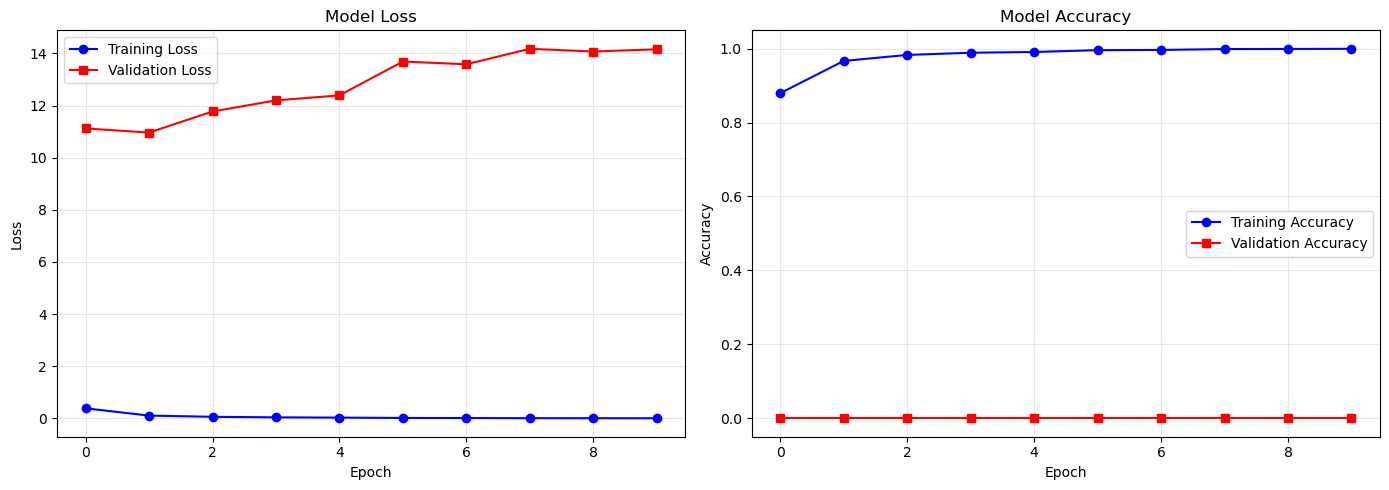


Final Training Accuracy: 0.9995
Final Validation Accuracy: 0.0000


In [13]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], 'b-o', label='Training Loss')
axes[0].plot(history.history['val_loss'], 'r-s', label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(history.history['accuracy'], 'b-o', label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], 'r-s', label='Validation Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

---

## Task 5: Evaluate the Model

Test the model on unseen test data.

In [14]:
# Evaluate on test set
print("Evaluating model on test set...")
test_loss, test_acc = model.evaluate(x_test, y_test_categorical, verbose=2)

print("\n" + "="*60)
print("TEST RESULTS")
print("="*60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("="*60)

Evaluating model on test set...
94/94 - 1s - 6ms/step - accuracy: 0.8807 - loss: 1.1505

TEST RESULTS
Test Loss: 1.1505
Test Accuracy: 0.8807 (88.07%)


### Confusion Matrix and Classification Report

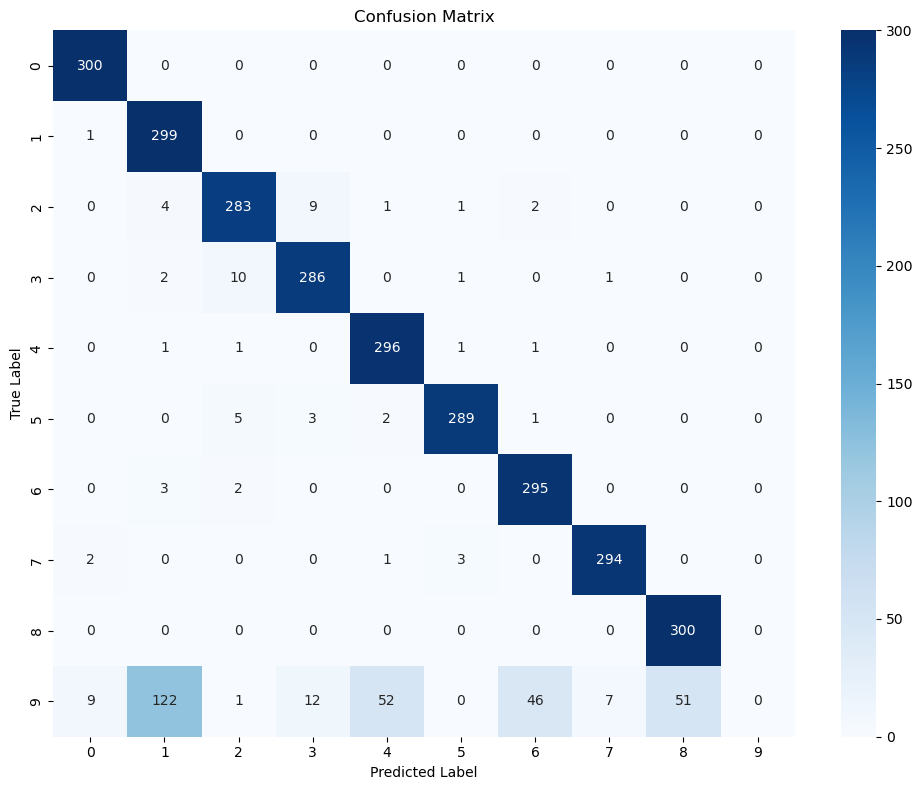


Classification Report:
              precision    recall  f1-score   support

     Digit 0       0.96      1.00      0.98       300
     Digit 1       0.69      1.00      0.82       300
     Digit 2       0.94      0.94      0.94       300
     Digit 3       0.92      0.95      0.94       300
     Digit 4       0.84      0.99      0.91       300
     Digit 5       0.98      0.96      0.97       300
     Digit 6       0.86      0.98      0.91       300
     Digit 7       0.97      0.98      0.98       300
     Digit 8       0.85      1.00      0.92       300
     Digit 9       0.00      0.00      0.00       300

    accuracy                           0.88      3000
   macro avg       0.80      0.88      0.84      3000
weighted avg       0.80      0.88      0.84      3000



C:\Users\ACER\anaconda3\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\anaconda3\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\anaconda3\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
# Make predictions
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print("="*60)
print(classification_report(y_test, y_pred, 
                          target_names=[f'Digit {i}' for i in range(10)]))

---

## Task 6: Save and Load the Model

Save the trained model for future use.

In [16]:
# Save model
model.save('devanagari_fcn_final_model.h5')
model.save('devanagari_fcn_final_model.keras')

print("✓ Model saved as:")
print("  - devanagari_fcn_final_model.h5")
print("  - devanagari_fcn_final_model.keras")

✓ Model saved as:
  - devanagari_fcn_final_model.h5
  - devanagari_fcn_final_model.keras


In [17]:
# Load model
loaded_model = tf.keras.models.load_model('devanagari_fcn_final_model.h5')
print("✓ Model loaded successfully\n")

# Verify loaded model
loaded_test_loss, loaded_test_acc = loaded_model.evaluate(x_test, y_test_categorical, verbose=0)

print("Loaded Model Test Results:")
print(f"Test Loss: {loaded_test_loss:.4f}")
print(f"Test Accuracy: {loaded_test_acc:.4f} ({loaded_test_acc*100:.2f}%)")

if abs(test_acc - loaded_test_acc) < 1e-6:
    print("\n✓ Loaded model matches original!")
else:
    print("\n✗ Warning: Results differ")

✓ Model loaded successfully

Loaded Model Test Results:
Test Loss: 1.1505
Test Accuracy: 0.8807 (88.07%)

✓ Loaded model matches original!


---

## Task 7: Make Predictions

Use the model to predict digit classes on test images.

In [18]:
# Make predictions
predictions = model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

print("Prediction Summary:")
print(f"Total samples: {len(x_test)}")
print(f"\nFirst sample:")
print(f"  True label: {y_test[0]}")
print(f"  Predicted: {predicted_labels[0]}")
print(f"  Confidence: {predictions[0][predicted_labels[0]]*100:.2f}%")

Prediction Summary:
Total samples: 3000

First sample:
  True label: 0
  Predicted: 0
  Confidence: 99.98%


### Visualize Predictions

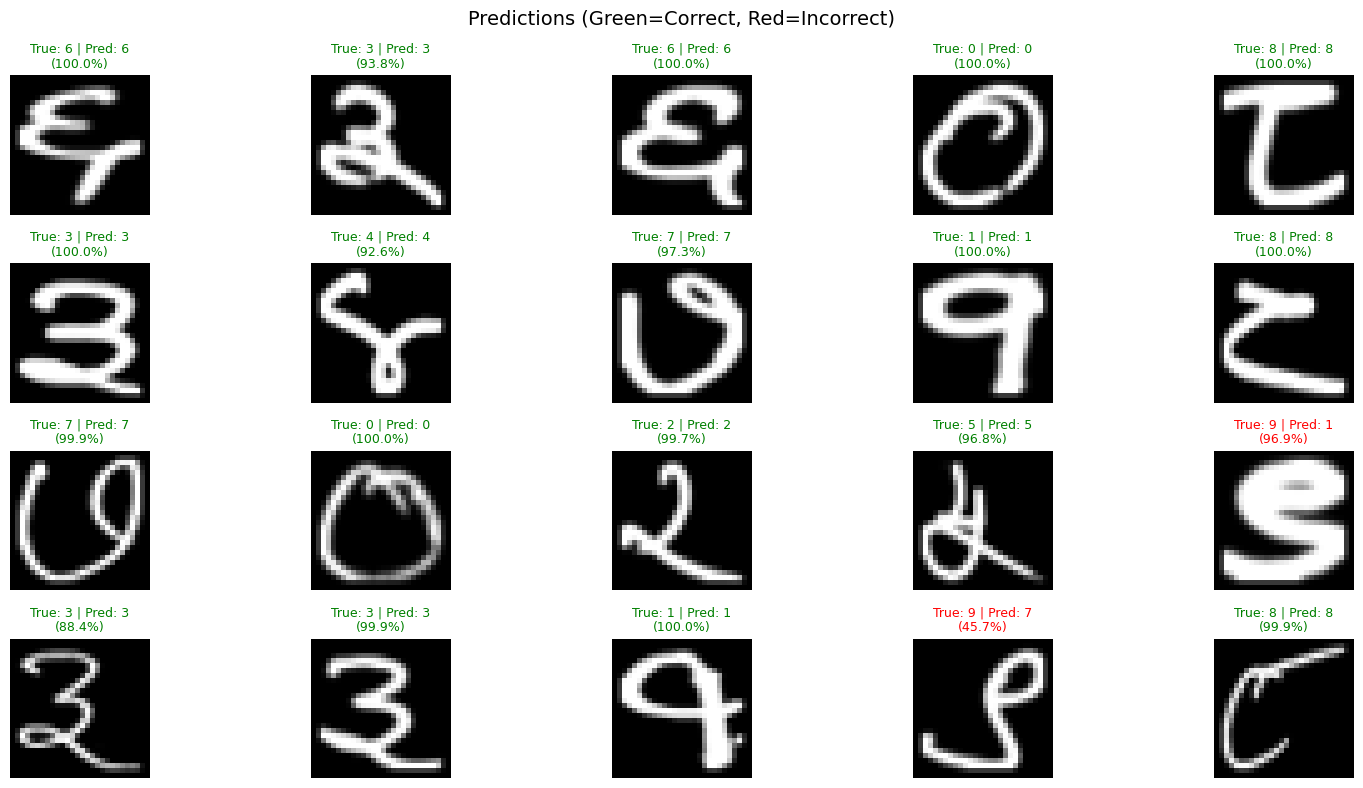

In [19]:
# Show predictions on random samples
plt.figure(figsize=(16, 8))
random_indices = np.random.choice(len(x_test), 20, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    
    true_label = y_test[idx]
    pred_label = predicted_labels[idx]
    confidence = predictions[idx][pred_label] * 100
    
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label} | Pred: {pred_label}\n({confidence:.1f}%)", 
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('Predictions (Green=Correct, Red=Incorrect)', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# Analyze correct and incorrect predictions
correct_indices = np.where(predicted_labels == y_test)[0]
incorrect_indices = np.where(predicted_labels != y_test)[0]

print(f"Correct: {len(correct_indices)} ({len(correct_indices)/len(y_test)*100:.2f}%)")
print(f"Incorrect: {len(incorrect_indices)} ({len(incorrect_indices)/len(y_test)*100:.2f}%)")

Correct: 2642 (88.07%)
Incorrect: 358 (11.93%)


### Show Some Incorrect Predictions

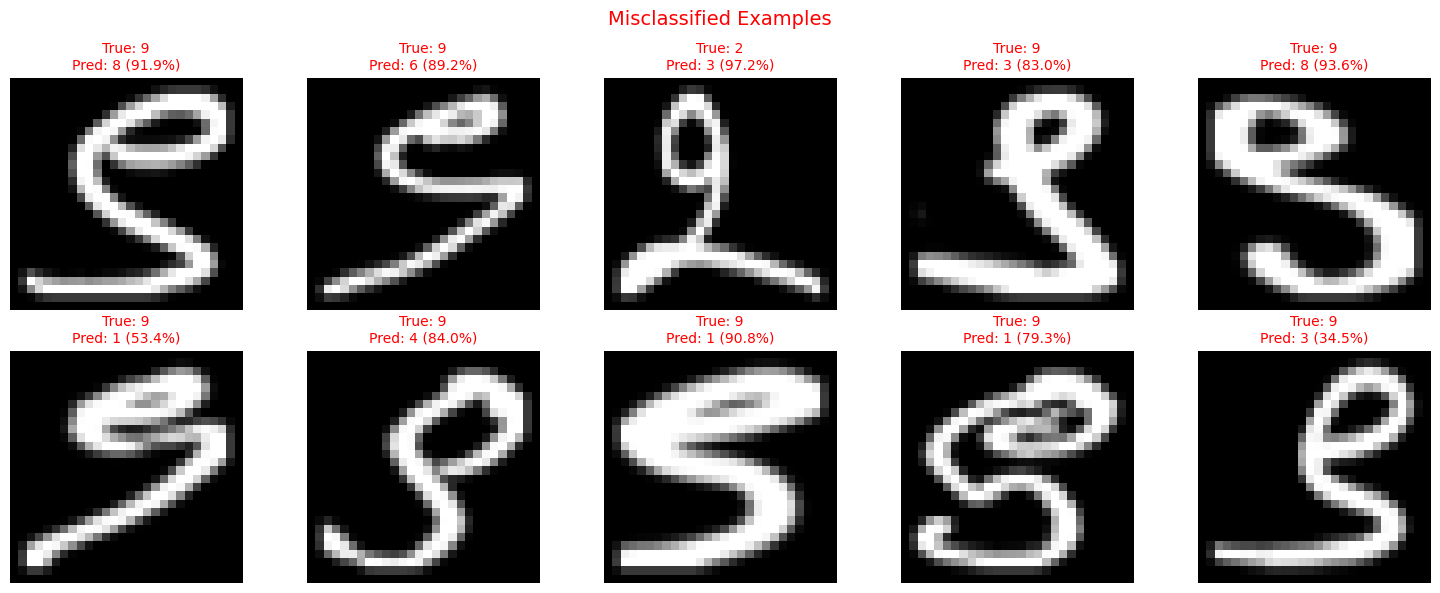

In [21]:
# Visualize misclassifications
if len(incorrect_indices) > 0:
    plt.figure(figsize=(15, 6))
    num_show = min(10, len(incorrect_indices))
    sample_incorrect = np.random.choice(incorrect_indices, num_show, replace=False)
    
    for i, idx in enumerate(sample_incorrect):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
        
        true_label = y_test[idx]
        pred_label = predicted_labels[idx]
        confidence = predictions[idx][pred_label] * 100
        
        plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)", 
                  color='red', fontsize=10)
        plt.axis('off')
    
    plt.suptitle('Misclassified Examples', fontsize=14, color='red')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications! Perfect accuracy!")

### Confidence Analysis

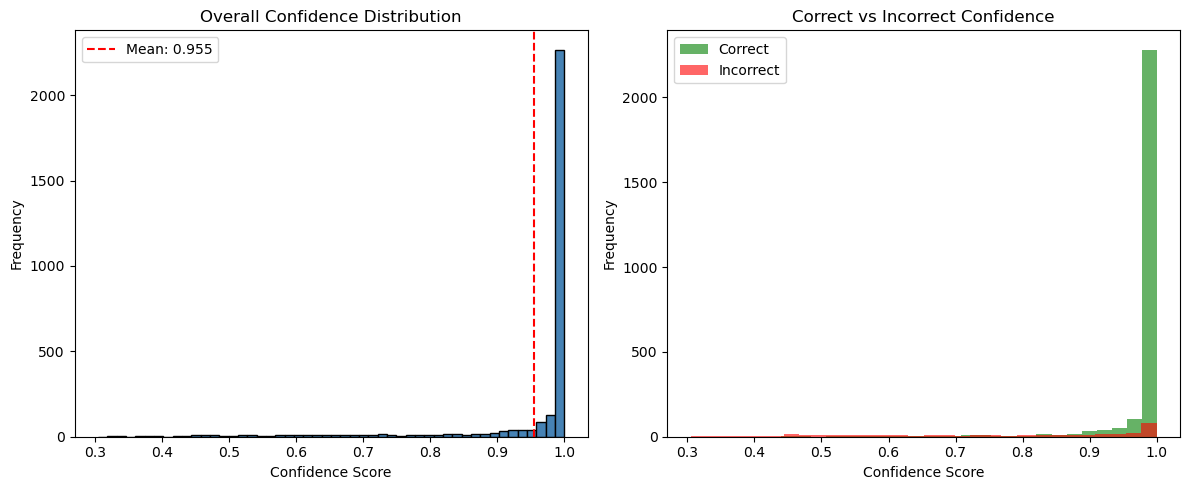

Mean confidence: 0.9549
Min confidence: 0.3048
Max confidence: 1.0000


In [22]:
# Analyze confidence scores
confidence_scores = np.max(predictions, axis=1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(confidence_scores, bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Confidence Score')
plt.ylabel('Frequency')
plt.title('Overall Confidence Distribution')
plt.axvline(confidence_scores.mean(), color='red', linestyle='--', 
           label=f'Mean: {confidence_scores.mean():.3f}')
plt.legend()

if len(incorrect_indices) > 0:
    plt.subplot(1, 2, 2)
    correct_conf = confidence_scores[correct_indices]
    incorrect_conf = confidence_scores[incorrect_indices]
    
    plt.hist(correct_conf, bins=30, color='green', alpha=0.6, label='Correct')
    plt.hist(incorrect_conf, bins=30, color='red', alpha=0.6, label='Incorrect')
    plt.xlabel('Confidence Score')
    plt.ylabel('Frequency')
    plt.title('Correct vs Incorrect Confidence')
    plt.legend()

plt.tight_layout()
plt.show()

print(f"Mean confidence: {confidence_scores.mean():.4f}")
print(f"Min confidence: {confidence_scores.min():.4f}")
print(f"Max confidence: {confidence_scores.max():.4f}")

---

## Final Summary

In [23]:
print("="*70)
print("FINAL SUMMARY")
print("="*70)

print("\n1. DATASET:")
print(f"   Training: {x_train.shape[0]:,} samples")
print(f"   Test: {x_test.shape[0]:,} samples")
print(f"   Classes: {num_classes}")

print("\n2. MODEL:")
print(f"   Architecture: Flatten → 64 → 128 → 256 → 10")
print(f"   Activation: sigmoid (hidden), softmax (output)")
print(f"   Parameters: {model.count_params():,}")

print("\n3. TRAINING:")
print(f"   Optimizer: Adam")
print(f"   Loss: Categorical Crossentropy")
print(f"   Batch size: {batch_size}")
print(f"   Epochs: {len(history.history['loss'])}")

print("\n4. RESULTS:")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Correct predictions: {len(correct_indices):,}")
print(f"   Incorrect predictions: {len(incorrect_indices):,}")

print("\n5. FILES SAVED:")
print("   ✓ devanagari_fcn_final_model.h5")
print("   ✓ devanagari_fcn_final_model.keras")
print("   ✓ best_devanagari_fcn_model.keras")

print("\n" + "="*70)
print("ALL TASKS COMPLETED!")
print("="*70)

FINAL SUMMARY

1. DATASET:
   Training: 17,000 samples
   Test: 3,000 samples
   Classes: 10

2. MODEL:
   Architecture: Flatten → 64 → 128 → 256 → 10
   Activation: sigmoid (hidden), softmax (output)
   Parameters: 1,462,538

3. TRAINING:
   Optimizer: Adam
   Loss: Categorical Crossentropy
   Batch size: 128
   Epochs: 10

4. RESULTS:
   Test Accuracy: 0.8807 (88.07%)
   Test Loss: 1.1505
   Correct predictions: 2,642
   Incorrect predictions: 358

5. FILES SAVED:
   ✓ devanagari_fcn_final_model.h5
   ✓ devanagari_fcn_final_model.keras
   ✓ best_devanagari_fcn_model.keras

ALL TASKS COMPLETED!
